# Transporte de 2 especies en equilibrio con el yeso en 1D. 

Modelación de la componente $U = c_1 - c_2$ con $c_1 = SO_4^{2-}$ y $c_2 = Ca^{2+}$.

Pasos a seguir:

1. GWF (Modflow). 
2. DFC (MMC_Python).  
3. WMA (Carrera-Petchamé  Fotran--->RT.exe).

In [1]:
import os, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import flopy
import xmf6 # instalar con: pip install git+https://github.com/luiggix/xmf6
import WMA_1D as WMA # Calcula las proporciones de mezcla
import resultsFortran as rF  #importa los resultados del WMA
line_size = 50

# Datos del problema.

## Discretización del tiempo.

|Parameter | Value| Units | Variable |
|---:|:---:|:---:|:---|
|Number of stress periods (NPER) | $1$ | | `tdis["nper"]` |
|Total time | $40$ | days | `tdis["perioddata"][0][0]` |
|Number of time steps (NSTP) | $1$ | | `tdis["perioddata"][0][1]` |
|Multiplier (TSMULT)| $1$ | | `tdis["perioddata"][0][2]` |

In [2]:
# Parámetros para el tiempo (flopy.mf6.ModflowTdis)
tdis = {
    'units': "days",
    'nper' : 1,
    'perioddata': [(40.0, 1, 1.0)]
}
xmf6.nice_print(tdis, "Discretización temporal")


Discretización temporal
―――――――――――――――――――――――
     units = days
      nper = 1
perioddata = ―― data array ――
           = (40.0, 1, 1.0)
―――――――――――――――――――――――


## Discretización espacial.

<img src="./dominiou.png" width=600px>

|Parameter | Value| Units | Variable |
|---:|:---:|:---:|:---|
|Length of system (rows) | $30.0$ | m | |
|Number of layers | $1$ | | `dis["nlay"]`|
|Number of rows | $1$ | | `dis["nrow"]`|
|Number of columns | $30$ | | `dis["ncol"]`|
|Column width | $1.0$ | m | `dis["delr"]`|
|Row width | $1.0$ | m | `dis["delc"]`|
|Top of the model | $1.0$ | m | `dis["top"]`|
|Layer bottom elevation (cm) | $0.0$ | m | `dis["botm"]`|

In [3]:
nlay = 1
nrow = 1
ncol = 30
delr = 1.0
delc = 1.0
top = 1.0 
botm = 0.0

dis = {
    'length_units' : "meters",
    'nlay': nlay, 
    'nrow': nrow, 
    'ncol': ncol,
    'delr': delr, 
    'delc': delc, 
    'top' : top, 
    'botm': botm 
}

xmf6.nice_print(dis, "Discretización espacial")


Discretización espacial
―――――――――――――――――――――――
length_units = meters
        nlay = 1
        nrow = 1
        ncol = 30
        delr = 1.0
        delc = 1.0
         top = 1.0
        botm = 0.0
―――――――――――――――――――――――


## Concentración inicial.

|Parameter | Value| Units | Variable |
|---:|:---:|:---:|:---|
|$c_1$ | $1.0000329$| unitless | NA |
|$c_2$ | $0.00003294$| unitless | NA |
|$U$ | $1.0$ | unitless | `phys["initial_concentration"]` |
|$c_{1_{12}}$ | $200.0$| unitless | NA |
|$c_{2_{12}}$ | $1.647e-7$| unitless | NA |
|$U_{12}$ | $199.999967$ | unitless | `phys["initial_concentration"]` |

In [4]:
init_conc = np.ones((nlay,nrow,ncol),dtype=float) * 1.0
init_conc[:,0,11]=199.999967

print(init_conc)

[[[  1.         1.         1.         1.         1.         1.
     1.         1.         1.         1.         1.       199.999967
     1.         1.         1.         1.         1.         1.
     1.         1.         1.         1.         1.         1.
     1.         1.         1.         1.         1.         1.      ]]]


## Parámetros físicos.

|Parameter | Value| Units | Variable |
|---:|:---:|:---:|:---|
|Specific discharge |$0.2$| m d$^{-1}$ | `phys["specific_discharge"]` |
|Hydraulic conductivity |$1.0$| m d$^{-1}$ | `phys["hydraulic_conductivity"]` |
|Source concentration |$1.0000329$| unitless | `phys["source_concentration"]` |
|Porosity | $0.5$ | unitless |  `phys["porosity"]` |
|Longitudinal Dispersivity | $0.2$ |  | `phys["longitudinal_dispersivity"]` |
|Retardation Factor | $1.0$ |  | `phys["'retardation_factor"]` |
|Decay Rate | $0.0$ |  | `phys["decay_rate"]` |
|Dispersion coefficient | $0.2$ | | `phys["dispersion_coefficient"]` |

$$
\text{Dispersion Coefficient} = \dfrac{\text{Longitudinal Dispersivity} \times \text{Specific Discharge}}{\text{Retardation Factor}}
$$

In [5]:
phys = dict(
    specific_discharge = 0.2,  # Specific discharge ($cm s^{-1}$)
    hydraulic_conductivity = 1.0,  # Hydraulic conductivity ($cm s^{-1}$)
    source_concentration = 1.0,  # Source concentration (unitless)
    porosity = 0.5,  # Porosity of mobile domain (unitless)
    initial_concentration = init_conc, # Initial concentration (unitless)
    longitudinal_dispersivity = 0.2,
    retardation_factor = 1.0,
    decay_rate =  0.0,
    dispersion_coefficient = 0.2
)

xmf6.nice_print(phys, "Parámetros físicos")


Parámetros físicos
――――――――――――――――――
       specific_discharge = 0.2
   hydraulic_conductivity = 1.0
     source_concentration = 1.0
                 porosity = 0.5
    initial_concentration = ―― data array ――
                          = [[  1.         1.         1.         1.         1.         1.
    1.         1.         1.         1.         1.       199.999967
    1.         1.         1.         1.         1.         1.
    1.         1.         1.         1.         1.         1.
    1.         1.         1.         1.         1.         1.      ]]
longitudinal_dispersivity = 0.2
       retardation_factor = 1.0
               decay_rate = 0.0
   dispersion_coefficient = 0.2
――――――――――――――――――


**Observaciones**.

* Al utilizar un valor de porosidad uniforme de $0.5$, se obtiene un valor de velocidad de $0.4$ $m/d$ como resultado de la inyección de agua a una razón de $0.2$ $m^3/d$ en la primera celda.
* A la última celda se le asigna una carga constante con un valor de $1$ $m$
* A la concentración del agua inyectada se le asigna un valor de $1.0$, y cualquier agua que salga a través de la celda de carga constante sale con la concentración simulada del agua en esa última celda.
* La advección se resuelve utilizando el esquema TVD para reducir la dispersión numérica.

# Ecuación de flujo.

$$
\frac{\partial}{\partial x}( K \frac{\partial h }{\partial x})+ q_s = S_s \frac{\partial h }{\partial t} 
$$


## Simulación con MODFLOW-GWF.

En este paso se lleva a cabo la solución del problema de flujo con el módulo GWF de MODFLOW 6, se utiliza la biblioteca Flopy para poder construir y ejecutar dicho problema. Cabe aclarar que, al llevar a cabo el problema de flujo como primer paso, está considerando que el transporte y el flujo no tienen dependencia entre ellos y se pueden resolver de manera secuencial.   

In [6]:
sim_name = "flow"

# ---------------
sim_flow = dict(
    # Parámetros de la simulación (flopy.mf6.MFSimulation)
    init = {
        'sim_name' : sim_name,
        'exe_name' : r"C:\Users\luiggi\Documents\GitSites\mf6_tutorial\mf6\windows\mf6",
        'sim_ws' : "output"
    },
    
    # Parámetros para el tiempo (flopy.mf6.ModflowTdis)
    tdis = tdis,
    
    # Parámetros para la solución numérica (flopy.mf6.ModflowIms)
    ims = {}
)

# ---------------
gwf_d = dict(
    # Parámetros para el modelo de flujo (flopy.mf6.ModflowGwf)
    gwf = { 
        'modelname': sim_name,
        'save_flows': True
    },
    
    # Parámetros para la discretización espacial (flopy.mf6.ModflowGwfdis)
    dis = dis,
    
    # Parámetros para las condiciones iniciales (flopy.mf6.ModflowGwfic)
    ic = {
        'strt': 1.0
    },
    
    # Parámetros para las condiciones de frontera (flopy.mf6.ModflowGwfchd)
    chd = {
        'stress_period_data': [[(0, 0, ncol - 1), 1.0]],     
    },
    
    # Parámetros para las propiedades de flujo (flopy.mf6.ModflowGwfnpf)
    npf = {
        'save_specific_discharge': True,
        'save_saturation': True,
        'icelltype':  0,
        'k': phys["hydraulic_conductivity"] 
    },
    
    # Parámetros para las propiedades de los pozos (flopy.mf6.ModflowGwfwel)
    well = {
        'stress_period_data': [[(0, 0, 0), 
                                phys["specific_discharge"] * delc * delr * top, 
                                phys["source_concentration"],]],
        'pname': "WEL-1",
        'auxiliary' : ["CONCENTRATION"],
    #    'save_flows': True
    },
    
    # Parámetros para almacenar y mostrar la salida de la simulación (flopy.mf6.ModflowGwfoc)
    oc = {
        'budget_filerecord': f"{sim_name}.bud",
        'head_filerecord': f"{sim_name}.hds",
        'saverecord': [("HEAD", "ALL"), ("BUDGET", "ALL")],
    }
)

# --- Inicialización de la simulación ---
o_sim = xmf6.common.init_sim(silent = True, **sim_flow)
o_gwf, packages = xmf6.gwf.set_packages(o_sim, silent = True, **gwf_d)

# --- Escritura de archivos ---
print(line_size * chr(0x2015))
print("- Escribiendo archivos de entrada para GWF")
o_sim.write_simulation(silent = True)

# --- Ejecución de la simulación ---
print("- Ejecutando GWF")
o_sim.run_simulation(silent = True)

# --- Recuperamos los resultados de flujo de la simulación ---
head = xmf6.gwf.get_head(o_gwf)
qx, qy, qz, n_q = xmf6.gwf.get_specific_discharge(o_gwf, text="DATA-SPDIS")

print(line_size * chr(0x2015))
print("Descarga específica", qx.shape)
print(qx)
print("Carga hidráulica", head.shape)
print(head)
print(line_size * chr(0x2015))

――――――――――――――――――――――――――――――――――――――――――――――――――
- Escribiendo archivos de entrada para GWF
- Ejecutando GWF
――――――――――――――――――――――――――――――――――――――――――――――――――
Descarga específica (1, 1, 30)
[[[0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2
   0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2]]]
Carga hidráulica (1, 1, 30)
[[[6.8 6.6 6.4 6.2 6.  5.8 5.6 5.4 5.2 5.  4.8 4.6 4.4 4.2 4.  3.8 3.6
   3.4 3.2 3.  2.8 2.6 2.4 2.2 2.  1.8 1.6 1.4 1.2 1. ]]]
――――――――――――――――――――――――――――――――――――――――――――――――――


# Ecuación de transporte.

La ecuación undimensional de transporte reactivo es:

$$
\begin{equation}
\phi \frac{\partial \textbf{c}}{\partial t} = -q_{x}\frac{\partial \textbf{c}}{\partial x }+D_{xx}\frac{\partial^{2}\textbf{c}}{\partial x^{2}}+r(\textbf{c}_{r}-\textbf{c})+\textbf{R}
\end{equation}
$$

donde:
* $\phi$ se refiere a la porosidad [adim.] 
* $q_{x}$ se refiere a la descarga hidráulica [$\frac{m^{3}}{day}$]
* $D_{xx}$ se refiere al factor de dispersión en dirección $x$. 
* $r$   factor de recarga o descarga [$(\frac{1}{day})$]. 
* $R$  velocidad de reacción [$\big(\frac{mg}{cm^{3}}\big)(\frac{1}{day})$]. 
* $\textbf{c}$  concentración de cada especie [$\frac{mg}{cm^{3}}$]. 
* $\textbf{c}_{r}$  concentración de descarga, recarga o evaporación de cada especie [$\frac{mg}{cm^{3}}$].

# Ecuación de transporte reactivo.


La ecuación unidimensional de transporte reactivo es:

$$
\begin{equation}
\phi \frac{\partial c_1}{\partial t} = -q_{x}\frac{\partial c_1}{\partial x }+D_{xx}\frac{\partial^{2} c_1}{\partial x^{2}}+r(c_{1,r}-c_1)+R_1
\end{equation}
$$

$$
\begin{equation}
\phi \frac{\partial c_2}{\partial t} = -q_{x}\frac{\partial c_2}{\partial x }+D_{xx}\frac{\partial^{2} c_2}{\partial x^{2}}+r(c_{2,r}-c_2)+R_1
\end{equation}
$$

Restando las ecuaciones se obtiene:

$$
\begin{equation}
\phi \frac{\partial U}{\partial t} = -q_{x}\frac{\partial U}{\partial x }+D_{xx}\frac{\partial^{2} U}{\partial x^{2}}+r(U_{r}-U) \tag{1}
\end{equation}
$$

donde $U=c_1-c_2$.


## Discretización con diferencias finitas centrales.

Discretizamos la ecuación $(1)$ usando diferencias finitas centrales:

$$
\begin{equation}
\phi \frac{U^{n+1}_{i}-U^{n}_{i}}{\Delta t} =  \bigg( - q_{x}|_{i+1/2} \frac{U_{i+1}-U_{i}}{2 \Delta x} - q_{x}|_{i-1/2} \frac{U_{i}-U_{i-1} }{2 \Delta x} \bigg ) + D_{xx} \frac{U_{i+1}-2U_{i}+U_{i-1}}{\Delta x^{2}}+r_{i}(U_{i,r}-U_{i})
\end{equation}
$$


<div class="alert alert-info">

**Nota**.

Se decidió dejar $n+1$ y $n$ como nomenclatura en el tiempo para dejar los índices $i,j,k$ para el caso tridimensional.  
</div>

Reacomodando términos:

$$
\begin{equation}
\phi \frac{U^{n+1}_{i}-U^{n}_{i}}{\Delta t} =  \bigg( \frac{ q_{x}|_{i-1/2}}{ 2 \Delta x}+\frac{D_{xx}}{\Delta x^{2}} \bigg ) U_{i-1}+\bigg(\frac{q_{x}|_{i+1/2}}{ 2 \Delta x}-\frac{ q_{x}|_{i-1/2}}{ 2 \Delta x} - \frac{2 D_{xx}}{\Delta x^{2}}-r_{i}  \bigg) U_{i}+ \bigg(   -\frac{q_{x}|_{i+1/2}}{ 2 \Delta x}+\frac{D_{xx}}{\Delta x^{2}} \bigg) U_{i+1}+r_{i} U_{i,r} 
\end{equation}
$$

Reescribiendo la ecuación se tiene la siguiente ecuación general:

$$
\begin{equation}
\phi \frac{U^{n+1}_{i}-U^{n}_{i}}{\Delta t} =  T_{W} U_{i-1}+ T_{C} U_{i}+ T_{E} U_{i+1}+r_{i} U_{i,r} \tag{2}
\end{equation}
$$

donde la nomenclatura se lee:

* $T_{W}$ transmisibilidad oeste (*West*),
* $T_{C}$ transmisibilidad central (*Center*),
* $T_{E}$ transmisibilidad este (*East*),

## Condiciones de frontera.

La ecuación $(2)$ solo es válida para las celdas internas, falta aplicarla para las celdas en las fronteras. 

### Robin.

Considerando una condición tipo Robin del lado derecho se tiene:

$$
\begin{equation}
qc-D_{xx}\frac{\partial c}{\partial x} = q_{inf} c_{inf}
\end{equation}
$$

Considerando la variable $U$, aplicando la técnica de celda fantasma, discretizando mediante diferencias finitas hacia atrás, ya que se requiere relacionar la celda del dominio con la celda fantasma:

$$
\begin{eqnarray}
q_{i}U_{i}-D_{xx}\frac{U_{i}-U_{i-1}}{\Delta x} = q_{inf} U_{inf}\\
\\
U_{i-1}=\frac{(q_{inf} U_{inf}) \Delta x}{Dxx}-\frac{(q_{i}U_{i}) \Delta x}{Dxx}+U_{i}\\
\\
U_{i-1}=\frac{(q_{inf} U_{inf}) \Delta x}{Dxx}+\bigg(1-\frac{(q_{i}) \Delta x}{Dxx} \bigg) U_{i}\\
\\
U_{i-1}= Cte_{1} U_{inf} +(1-Cte_{2}) U_{i}\\
\end{eqnarray}
$$

Para el caso que la carga específica $q_{inf}=q_{i}$, se tiene $Cte_{1}=Cte_{2}$. Sustituyendo $U_{i-1}$ en la ecuación general:

$$
\begin{eqnarray}
\phi \frac{U^{n+1}_{i}-U^{n}_{i}}{\Delta t} =  T_{W}[Cte_{1} U_{inf} +(1-Cte_{2}) U_{i}] + T_{C} U_{i}+ T_{E} U_{i+1}+r_{i} U_{i,r}\\
\\
\phi \frac{U^{n+1}_{i}-U^{n}_{i}}{\Delta t} =   (1-Cte_{2}+T_{C}) U_{i} + T_{E} U_{i+1}+r_{i} U_{i,r} +T_{W} Cte_{1} U_{inf}\\
\end{eqnarray}
$$

Note que esta ecuación solo es válida para la primera celda donde está la condición a la frontera. 

### Neumann.

Considerando la salida, que es la última celda, se tiene la siguiente condición de frontera Neumann:

$$
\begin{equation}
D_{xx}\frac{\partial U}{\partial x} = 0
\end{equation}
$$

Lo que significa que la variable $U$ se mantiene constante en la dirección $x$, discretizando y despejando para la celda fantasma $U_{i+1}$ :

$$
\begin{eqnarray}
D_{xx}\frac{\partial U}{\partial x} = 0 \quad \rightarrow \quad   D_{xx} \frac{U_{i+1}-U_{i}}{\Delta x} = 0 \quad \rightarrow \quad   U_{i+1}=U_{i}
\end{eqnarray}
$$

Sustituyendo en la ecuación general:

$$
\begin{equation}
\phi \frac{U^{n+1}_{i}-U^{n}_{i}}{\Delta t} =  T_{W} U_{i-1}+ (T_{C}+T_{E}) U_{i}+r_{i} U_{i,r} 
\end{equation}
$$

## Notación matricial.

Tomando en cuenta todo el proceso algebraico anterior, la discretización del problema se puede escribir de forma matricial:

$$
\begin{equation}
\boldsymbol{D} \frac{\boldsymbol{U^{n+1}}-\boldsymbol{U^{n}}}{\Delta t} = \boldsymbol{A}\boldsymbol{U}+\boldsymbol{R} \boldsymbol{U_{r}} + \boldsymbol{Q} \boldsymbol{U_{inf}}
\end{equation}
$$

donde 

* $\boldsymbol{D}$ es una matriz diagonal que incluye la porosidad del sistema $\phi$ ,
* $\boldsymbol{A}$ es una matriz tridiagonal que contiene las transmibilidades del dominio incluyendo las condiciones de frontera,
* $\boldsymbol{R}$ es una matriz diagonal y sus valores están ligados con las celdas donde existe recarga,
* $\boldsymbol{Q}$ es también una matriz diagonal, que para este caso tiene un único valor correspondiente a la frontera de infiltración,

Nótese que todas las matrices son de tamaño $nx\times nx$ y los vectores de tamaño $nx$, que indican el número de celdas. Se debe tener en cuenta $\boldsymbol{U_{r}}$ y $\boldsymbol{U_{inf}}$ solo tendrán valores diferentes de cero en la diagonal principal en ciertas partes donde el problema así lo requiere. En este caso $\boldsymbol{U_{i,r}}=0$ ya que no existe recarga y  $\boldsymbol{U_{inf}}=1.0$ en el la frontera de infiltración. 

## Cálculo de las proporciones de mezcla $\lambda$.

### Método explícito.

Hasta acá aun no se ha decido si utilizaremos un método explícito o implícito para la componente $U$. Si elegimos un método explícito se tendría:

$$
\begin{eqnarray}
\boldsymbol{U^{n+1}}-\boldsymbol{U^{n}} = \bigg(\frac{\boldsymbol{D}}{\Delta t} \bigg)^{-1} \bigg[ \boldsymbol{A}\boldsymbol{U^{n}}+\boldsymbol{R} \boldsymbol{U^{n}_{r}} + \boldsymbol{Q} \boldsymbol{U^{n}_{inf}} \bigg]\\
\\
\boldsymbol{U^{n+1}} =   \bigg[\bigg(\frac{\boldsymbol{D}}{\Delta t} \bigg)^{-1} \boldsymbol{A}+1\bigg] \boldsymbol{U^{n}} +\bigg(\frac{\boldsymbol{D}}{\Delta t} \bigg)^{-1} \bigg[\boldsymbol{R} \boldsymbol{U^{n}_{r}} + \boldsymbol{Q} \boldsymbol{U^{n}_{inf}} \bigg]
\end{eqnarray}
$$

La ecuación de arriba se puede implementar de forma sencilla definiendo los parámetros físicos y numéricos correspondientes. Sin embargo, estamos expuestos a la inestabilidad numérica inherente del método explícito. En este caso las proporciones de mezcla $\lambda$ se definen como sigue:

$$
\begin{eqnarray}
\lambda_{U} =   \bigg[\bigg(\frac{\boldsymbol{D}}{\Delta t} \bigg)^{-1} \boldsymbol{A}+1\bigg] \\
\\
\lambda_{r} =  \bigg(\frac{\boldsymbol{D}}{\Delta t} \bigg)^{-1} \boldsymbol{R} \\
\\
\lambda_{inf} =  \bigg(\frac{\boldsymbol{D}}{\Delta t} \bigg)^{-1}  \boldsymbol{Q}  
\end{eqnarray}
$$

### Método implícito.

Ahora bien, veremos lo que sucede cuando utilizamos el método implícito:

$$
\begin{eqnarray}
\boldsymbol{D} \frac{\boldsymbol{U^{n+1}}-\boldsymbol{U^{n}}}{\Delta t} = \boldsymbol{A}\boldsymbol{U}^{n+1}+\boldsymbol{R} \boldsymbol{U_{r}}^{n+1} + \boldsymbol{Q} \boldsymbol{U_{inf}}^{n+1}\\
\\
\frac{\boldsymbol{D}}{\Delta t}\bigg(\boldsymbol{U^{n+1}}-\boldsymbol{U^{n}}\bigg)-\boldsymbol{A}\boldsymbol{U}^{n+1} = \boldsymbol{R} \boldsymbol{U_{r}}^{n+1} + \boldsymbol{Q} \boldsymbol{U_{inf}}^{n+1}\\
\\
\bigg(\frac{\boldsymbol{D}}{\Delta t}-\boldsymbol{A}\bigg)\boldsymbol{U}^{n+1} = \bigg( \frac{\boldsymbol{D}}{\Delta t} \bigg) \boldsymbol{U^{n}}+ \boldsymbol{R} \boldsymbol{U_{r}}^{n+1} + \boldsymbol{Q} \boldsymbol{U_{inf}}^{n+1}\\
\\
\boldsymbol{U}^{n+1} = \bigg(\frac{\boldsymbol{D}}{\Delta t}-\boldsymbol{A}\bigg)^{-1} \bigg[ \bigg( \frac{\boldsymbol{D}}{\Delta t} \bigg) \boldsymbol{U^{n}}+ \boldsymbol{R} \boldsymbol{U_{r}}^{n+1} + \boldsymbol{Q} \boldsymbol{U_{inf}}^{n+1} \bigg]
\end{eqnarray}
$$

Las proporciones de mezcla quedarían:

$$
\begin{eqnarray}
\lambda_{U} =   \bigg(\frac{\boldsymbol{D}}{\Delta t}-\boldsymbol{A}\bigg)^{-1} \bigg[ \bigg( \frac{\boldsymbol{D}}{\Delta t} \bigg) \bigg] \\
\\
\lambda_{r} =  \bigg(\frac{\boldsymbol{D}}{\Delta t}-\boldsymbol{A}\bigg)^{-1} \boldsymbol{R} \\
\\
\lambda_{inf} =  \bigg(\frac{\boldsymbol{D}}{\Delta t}-\boldsymbol{A}\bigg)^{-1} \boldsymbol{Q}  
\end{eqnarray}
$$

Nótese que calcular las proporciones de mezcla involucran resolver la inversa $ \bigg(\frac{\boldsymbol{D}}{\Delta t}-\boldsymbol{A}\bigg)^{-1} $, siendo este, un problema no trivial, pero si un **reto**, ya que tenemos de aliado las técnicas de HPC que se pueden implementar rápidamente en Python. Adicionalmente, encontrar la inversa planteada equivale a resolver el problema para $\boldsymbol{U}$, siempre y cuando los términos de recarga y de infiltración sean conocidos. 

Por otra parte, se debe enfatizar que esta método solo aplica para "propiedades constantes", tanto del medio como del fluido, si las propiedades tienen dependencia la variable $U$, habría que aplicar un método semi-implícito iterativo donde  $U$ estuviera dado de forma ímplicita y las propiedades sean definidas de manera explícita. O bien, plantear un método completamente implícito mediante la técnica de Newton-Raphson.

## Implementación en Python.

La celda siguiente calcula las proporciones de mezcla $\lambda$ de manera implícita para el ejemplo del yeso, tomando como entradas los parámetros físicos, las discretizaciones espacial y temporal, las cargas hidráulicas $head$ y  los flujos volumétricos $qx$ calculados con MODFLOW. 

Cabe señalar que se ejecuta un cálculo implicito, es decir, se resuelve, $\bigg(\frac{\boldsymbol{D}}{\Delta t}-\boldsymbol{A}\bigg)^{-1}$ porque así lo pide como entrada el WMA programado por Jordi-Carrera (`TR_1D_oper.exe`). 

En este paso se utiliza la función `WMA.mixingRatios1D()` que construye las proporciones de mezcla ($\lambda$) y las *mixing waters*, usando la discretización de diferencias finitas mostrada anteriormente mediante un método implícito.

Posteriormente, se utiliza la función `WMA.save_mixing()` para almacenar el resultado en un archivo con extensión `.dat`, en un formato particular que se necesita para la ejecución del programa `TR_1D.exe`.  

In [7]:
# --- Recuperamos las coordenadas del dominio
grid = o_gwf.modelgrid
x, y, z = grid.xyzcellcenters

# Directorio de trabajo
#working_dir = r"C:\Users\luiggi\Documents\GitSites\RTWMA\benchmarks\03_wma\BINARY_REACT_1D\RT-EXE"
working_dir = r"C:\Users\luiggi\Documents\GitSites\RTWMA\benchmarks\03_wma\RT-EXE"

# Cálculo de las lambdas ...
print(line_size * chr(0x2015))
print("- Calculando las 𝜆's")

tdis = {
        'units': "days",
        'nper' : 1,
        'perioddata': [(40.0, 40, 1.0)]
}
# sim_flow["tdis"]

lambdas1D, mixingWaters = WMA.mixingRatios1D(phys, grid, tdis, head[0][0][:], qx[0][0][:])
#print(lambdas1D)

# Archivo para almacenar las proporciones de mezcla 
wma_lambdas_filename = os.path.join(working_dir, "input", "gypsum_eq", "WMA_lambdas_gypsum_eq.dat")

# Almacenamiento de las proporciones de mezcla 
print(f"- Escribiendo las 𝜆's")
WMA.save_mixing(wma_lambdas_filename, lambdas1D, mixingWaters)
print(line_size * chr(0x2015))

――――――――――――――――――――――――――――――――――――――――――――――――――
- Calculando las 𝜆's
- Escribiendo las 𝜆's
Data written to C:\Users\luiggi\Documents\GitSites\RTWMA\benchmarks\03_wma\RT-EXE\input\gypsum_eq\WMA_lambdas_gypsum_eq.dat successfully.
――――――――――――――――――――――――――――――――――――――――――――――――――


## WMA.

La celda siguiente lee el directorio donde está ubicado el ejecutable `TR_1D_oper.exe`, creando un directorio de trabajo y mostrando algunas leyendas durante la llamada y ejecución del programa.

Se debe señalar que este ejecutable se construyó mediante el código fuente proporcionado por Jordi, usando los compiladores de Intel One API: 
* [base-toolkit](https://www.intel.com/content/www/us/en/developer/tools/oneapi/base-toolkit.html),
* [hpc-toolkit](https://www.intel.com/content/www/us/en/developer/tools/oneapi/hpc-toolkit.html#gs.l9g60i),
* [extras](https://www.intel.com/content/www/us/en/developer/articles/tool/compilers-redistributable-libraries-by-version.html)

además de [Visual Studio 2022](https://visualstudio.microsoft.com/es/vs/community/).

In [8]:
# Creación del archivo "workingDirectory.txt" necesario para 
# la ejecución del programa "TR_1D_oper.exe"
with open(os.path.join(working_dir, "workingDirectory.txt"), "w") as f:
    f.write(working_dir)

# Ruta al ejecutable "TR_1D_oper.exe"
tr1d_exe = os.path.join(working_dir, "TR_1D_oper.exe")

# Ejecución de "TR_1D_oper.exe"
print(line_size * chr(0x2015))
print("- Ejecutando TR_1D_oper.exe")
print(line_size * chr(0x2015))
result = subprocess.run([tr1d_exe], cwd = working_dir, 
                        capture_output = True, text = True)

# Salida de "TR_1D_oper.exe"
print("Standard Output:", result.stdout)
print("Standard Error:", result.stderr)
print(line_size * chr(0x2015))

――――――――――――――――――――――――――――――――――――――――――――――――――
- Ejecutando TR_1D_oper.exe
――――――――――――――――――――――――――――――――――――――――――――――――――
Standard Output:  Directorio de trabajo:
 C:\Users\luiggi\Documents\GitSites\RTWMA\benchmarks\03_wma\RT-EXE
 ca+2                                                                           
                                                                                
                                                                                
                    
 so4-2                                                                          
                                                                                
                                                                                
                    
 gypsum                                                                         
                                                                                
                                                                        

# Análisis de resultados.

La siguiente celda de código ejecuta la función `resultsFortran()` para leer los resultados del archivo `gypsum_eq.out` generado por la ejecución del programa del `TR_1D_oper.exe`.

Posteriormente realiza una comparación con los resultados obtenidos con la hoja de excel `comparativa_02.xlsx` del mismo problema, para un tiempo selccionado (`tsel`). 

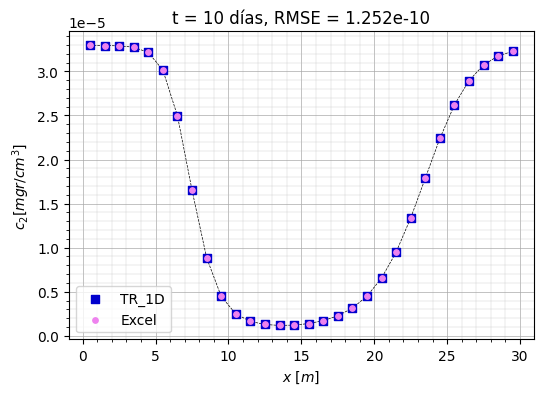

In [9]:
# Tiempo seleccionado de hoja excel
tsel=10

# Archivo con los resultados de TR_1D_oper.exe
file_name='gypsum_eq.out'   
file_path = os.path.join(working_dir, file_name)
Res_contrsns_ini, Res_contrsns_fin = rF.import_results(file_path)

# Lectura de datos de la tabla de excel
WMA_I=pd.read_excel('comparativa_02.xlsx', sheet_name='c_2')     
data_set_C2 = np.transpose(WMA_I.iloc[11:,5:95].to_numpy())

# Calculamos el RMSE
RMSE = np.linalg.norm(data_set_C2[tsel][:]-np.array(Res_contrsns_fin[1][:])) / np.sqrt(len(Res_contrsns_fin))

# --- Gráfica de los resultados
plt.figure(figsize=(6,4))
plt.plot(x[0], data_set_C2[tsel][:], 
         lw=0.5, ls="--", c="k", zorder=5)
plt.scatter(x[0], Res_contrsns_fin[1][:], 
            marker = "s", c = "mediumblue", s=30, label="TR_1D", zorder=5)
plt.scatter(x[0], data_set_C2[tsel][:], 
            marker = "o", c = "violet", s=15,label="Excel", zorder=5)
plt.title(f"t = {tsel} días, RMSE = {RMSE:5.3e}")
plt.xlabel("$x$ [$m$]")
plt.ylabel("$c_2 [mgr/cm^{3}]$")
plt.legend()
plt.minorticks_on()
plt.grid(True,which='major', color='darkgray', lw = 0.5)
plt.grid(True, which='minor', color='silver', lw = 0.25)
plt.show()